In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

import seaborn as sns
import os

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer



sns.set_style('whitegrid')

%matplotlib inline

In [ ]:
df = pd.read_csv('../data/raw/bank_churn_raw.csv')

# display(df.head(20))
print(df.shape)
display(df.info())
display(df.describe())
display(df.dtypes)
display(df.sample(20, random_state=42))
display(df.isnull().sum().sort_values(ascending=False))

In [ ]:
drop_cols = ['customer_id']

object_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
print(object_cols)

for col in object_cols:
    n_unique = df[col].nunique()
    print(f"{col}: {n_unique} unique values")
    if n_unique < 20:
        print(f"Value counts for {col}:\n{df[col].value_counts()}\n")
        
print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicate customer_id:", df['customer_id'].duplicated().sum())

In [ ]:
red_flags = {}

leak_candidates = ['exit_survey_score', 'account_closed_date', 'churn_flag_internal']

for c in leak_candidates:
    if c in df.columns:
        red_flags[c] = {
            "null_rate": df[c].isna().mean(),
            "non_null_if_churn": df.loc[df['churned'] == 1, c].notna().mean(),
            "non_null_if_not_churn": df.loc[df['churned'] == 0, c].notna().mean()            
        }
income_sample = df['annual_income'].astype(str).sample(30, random_state=42)
# display(income_sample.describe())

target_dist = df['churned'].value_counts(dropna=False)
target_ratio = df['churned'].value_counts(normalize=True, dropna=False)


print("Leakage check results:", red_flags)
print("Target distribution:", target_dist)
print("Target ratio:", target_ratio)
print("Annual Income sample:\n")
for x in income_sample:
    print(x)


In [ ]:
target_count = df['churned'].value_counts()
target_ratio = df['churned'].value_counts(normalize=True)

neg = target_count.get(0,0)
pos = target_count.get(1,0)

imbalance_ratio = neg / max(pos, 1)  # Avoid division by zero


print("Target distribution:\n", target_count)
print("Target ratio:\n", target_ratio)
print(f"Imbalance ratio (0 : 1): {imbalance_ratio:.2f} : 1")

In [ ]:
rows = []

for col in df.columns:
    if df[col].isna().sum() == 0:
        continue
    
    null_if_churn = df.loc[df['churned'] == 1, col].isna().mean()
    null_if_not = df.loc[df['churned'] == 0, col].isna().mean()
    abs_diff = abs(null_if_churn - null_if_not)
    
    
    rows.append({
        'column': col,
        'null_rate': df[col].isna().mean(),
        'null_if_churn': null_if_churn,
        'null_if_not_churn': null_if_not,
        'abs_diff': abs_diff
    })
    
miss_df = pd.DataFrame(rows).sort_values('abs_diff', ascending=False)
display(miss_df)

In [ ]:
leak_cols = ['exit_survey_score', 'account_closed_date', 'churn_flag_internal']
df_noleak = df.drop(columns=leak_cols, errors='ignore')

print("Original shape:", df.shape)
print("After leakage drop:", df_noleak.shape)
print("Dropped:", leak_cols)

In [ ]:
df_copy_clean = df_noleak.copy()

# Identify columns with missing values (excluding target)
missing_cols = [c for c in df_copy_clean.columns if c != 'churned' and df_copy_clean[c].isna().sum() > 0]

results = []

for col in missing_cols:
    temp = df_copy_clean.copy()
    temp['missing_flag'] = temp[col].isna().astype(int)
    
    feat_cols = [c for c in temp.columns if c not in [col, 'missing_flag']]
    X = temp[feat_cols]
    y = temp['missing_flag']
    
    # Only evaluate if both classes are present
    if y.nunique() < 2:
        continue
    
    
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
    
    
    pre = ColumnTransformer(
        transformers = [
            ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols),
            ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
        ]
    )
    
    
    model = Pipeline([
        ('pre', pre),
        ('clf', LogisticRegression(max_iter=2000, random_state=42))
    ])
    
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc = cross_val_score(model, X, y, cv=cv, scoring='roc_auc').mean()
    
    
    gaps = abs(temp.loc[temp['churned'] == 1, col].isna().mean() - temp.loc[temp['churned'] == 0, col].isna().mean())
    
    if auc < 0.55 and gaps < 0.02:
        label ='likely MCAR'
    elif auc >= 0.55 and gaps >= 0.02:
        label = 'likely MAR'
    elif auc >= 0.55 and gaps >= 0.02:
        label = 'Likely MNAR/MAR-strong'
    else:
        label = 'unclear'
        
        
    results.append({
        'column': col,
        'missing_rate': temp[col].isna().mean(),
        'missingness_auc_from_observed': auc,
        'gap_vs_target': gaps,
        'heuristic_label': label
    })
    
    
diag = pd.DataFrame(results).sort_values(['heuristic_label', 'missing_rate', 'missingness_auc_from_observed'], ascending=[True, False, False])
display(diag)

In [35]:
# Recompute diagnostic labels correctly
diag_fixed = diag.copy()

def classify_missingness(row):
    auc = row['missingness_auc_from_observed']
    gap = row['gap_vs_target']
    if auc < 0.55 and gap < 0.02:
        return 'likely_MCAR'
    elif auc >= 0.55 and gap < 0.02:
        return 'likely_MAR'
    elif auc >= 0.55 and gap >= 0.02:
        return 'likely_MNAR_or_strong_MAR'
    else:
        return 'unclear'

diag_fixed['heuristic_label'] = diag_fixed.apply(classify_missingness, axis=1)
display(diag_fixed.sort_values(['heuristic_label', 'missingness_auc_from_observed'], ascending=[True, False]))

,column,missing_rate,missingness_auc_from_observed,gap_vs_target,heuristic_label
1,region,0.040583,0.547487,0.013529,likely_MCAR
9,has_credit_card,0.060680,0.532174,0.006899,likely_MCAR
5,monthly_transactions,0.049320,0.530466,0.004647,likely_MCAR
7,debt_to_income,0.086893,0.525190,0.015149,likely_MCAR
2,account_type,0.028058,0.518431,0.010261,likely_MCAR
8,digital_engagement,0.087379,0.516641,0.014655,likely_MCAR
4,num_products,0.034660,0.487764,0.013462,likely_MCAR
6,complaints_12mo,0.036019,0.582586,0.212942,likely_MNAR_or_strong_MAR
0,gender,0.071748,0.540960,0.036410,unclear
3,credit_score,0.081262,0.518569,0.039133,unclear


C:\Users\pined\AppData\Local\Temp\ipykernel_15176\454692082.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='churned', palette='Set2')


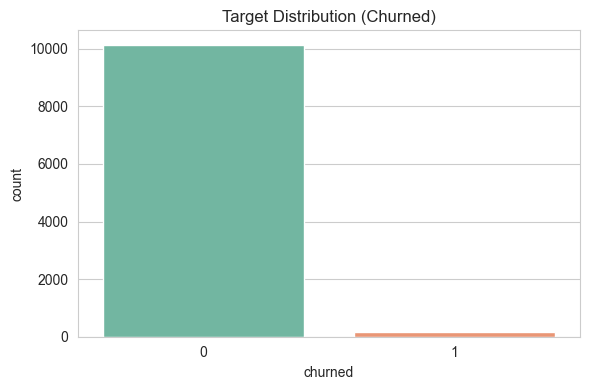

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='churned', palette='Set2')
plt.title('Target Distribution (Churned)')
plt.xlabel('churned')
plt.ylabel('count')
plt.tight_layout()
plt.show()

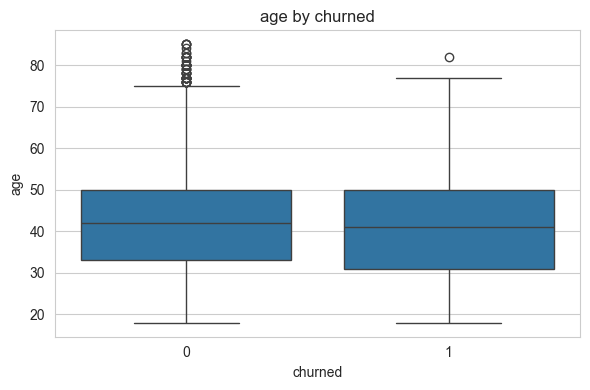

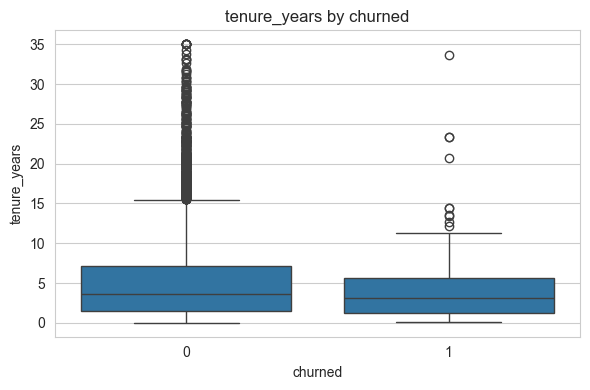

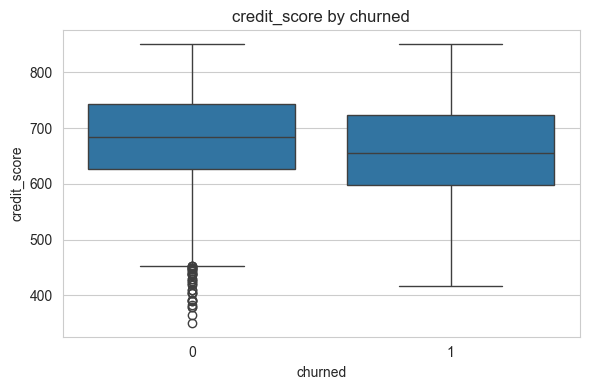

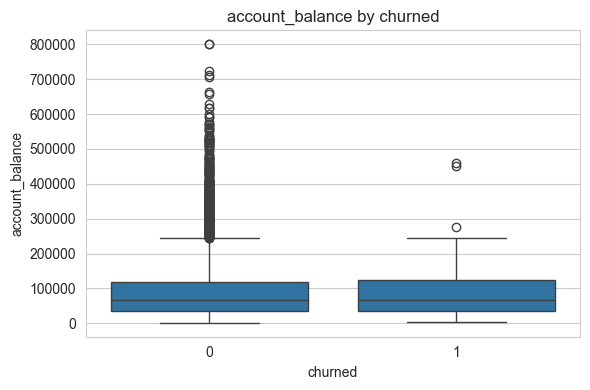

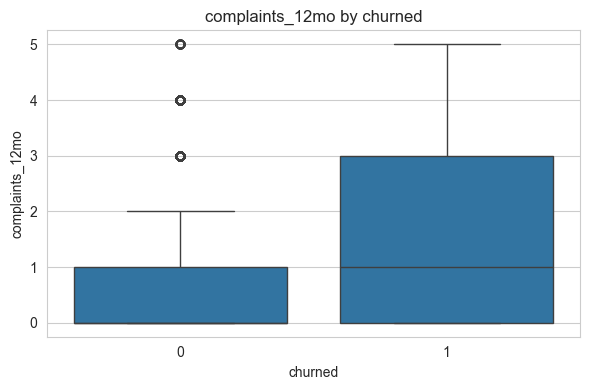

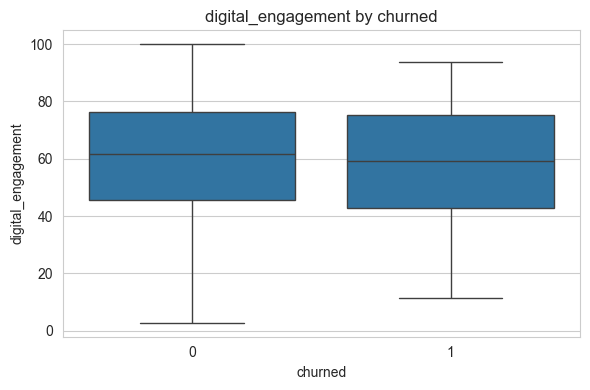

In [37]:
key_cols = ['age', 'tenure_years', 'credit_score', 'account_balance', 'complaints_12mo', 'digital_engagement']
key_cols = [c for c in key_cols if c in df.columns]

for c in key_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x='churned', y=c)
    plt.title(f'{c} by churned')
    plt.tight_layout()
    plt.show()

In [38]:
eda_decisions = pd.DataFrame([
    {'item':'target', 'decision':'keep churned as target', 'reason':'business outcome variable'},
    {'item':'leakage', 'decision':'drop exit_survey_score, account_closed_date, churn_flag_internal', 'reason':'post-outcome leakage'},
    {'item':'annual_income', 'decision':'parse to numeric annual_income_cleaned', 'reason':'mixed string formats'},
    {'item':'duplicates', 'decision':'deduplicate by customer_id before split', 'reason':'prevent train-test contamination'},
    {'item':'missingness', 'decision':'MCAR columns median/mode; add flags for high-risk missingness', 'reason':'preserve missingness signal'},
])

display(eda_decisions)

,item,decision,reason
0,target,keep churned as target,business outcome variable
1,leakage,"drop exit_survey_score, account_closed_date, c...",post-outcome leakage
2,annual_income,parse to numeric annual_income_cleaned,mixed string formats
3,duplicates,deduplicate by customer_id before split,prevent train-test contamination
4,missingness,MCAR columns median/mode; add flags for high-r...,preserve missingness signal


In [ ]:
import re

def parse_income(val):
    
    if isinstance(val, (int,float)):
        return float(val) # If it's already numeric, return as float
    
    if pd.isna(val):
        return np.nan #for missing values, return np.nan
    
    
    s = str(val).strip() # remove spaces
    s = s.upper() # some data have k and K so lets stick to K
    s = re.sub(r'[PHP\$,\s]', '', s) #Remove currency symbols PHP and $, commas, and spaces
    
    multiplier = 1 
    if s.endswith('K'):
        s = s[:-1] # remove the K
        multiplier = 1000 
    elif s.endswith('M'):
        s = s[:-1] # remove the M assuming M means million
        multiplier = 1000000
        
        
    try:
        return float(s) * multiplier
    except ValueError:
        return np.nan # If it can't be converted, return np.nan
    
print("Income Parser Initialized")
df_noleak['annual_income_cleaned'] = df_noleak['annual_income'].apply(parse_income)
display(df_noleak[['annual_income', 'annual_income_cleaned']].sample(20, random_state=42))



In [ ]:
exact_dups = df_noleak.duplicated().sum()
display(exact_dups)

id_dups = df_noleak['customer_id'].duplicated().sum()
if id_dups > 0:
    dup_ids = df_noleak[df_noleak['customer_id'].duplicated(keep=False)].sort_values('customer_id')
    display(dup_ids[['customer_id', 'full_name', 'churned', 'account_open_date']].head(10))
    
df_deduped = df_noleak.sort_values('account_open_date').drop_duplicates(subset=['customer_id'], keep='first')
print("After deduplication shape:", df_deduped.shape)



In [34]:
df_work = df_deduped.copy()
display(df_work.sample(3))


# Based on the EDA, these columns have significant missingness patterns that correlate with the target variable, 
# suggesting they may be high-risk for data leakage if not handled properly.
high_risk_cols = ['complaints_12mo', 'credit_score', 'gender']
high_risk_numeric = ['complaints_12mo', 'credit_score']

for col in high_risk_cols:
    if col in df_work.columns:
        df_work[f'{col}_missing'] = df_work[col].isna().astype(int)
        # print(f"   Created: {col}_missing (1 if missing, 0 if not)")

# print(f"   New shape: {df_work.shape}")


mcar_numeric = ['digital_engagement', 'debt_to_income', 'monthly_transactions']
mcar_categorical = ['region', 'account_type', 'gender', 'has_credit_card']



# Fill numeric MCAR columns with median and categorical MCAR columns with mode, but only if they have missing values
for col in mcar_numeric:
    if col in df_work.columns and df_work[col].isna().mean() > 0:
        median_val = df_work[col].median()
        df_work[col] = df_work[col].fillna(median_val)
        
# print(f"Filled missing values in {col} with median: {median_val}")
for col in mcar_categorical:
    if col in df_work.columns and df_work[col].isna().sum() > 0:
        mode_val = df_work[col].mode()[0] if len(df_work[col].mode()) > 0 else 'unknown'
        df_work[col] = df_work[col].fillna(mode_val)
        
# print(f"Filled missing values in {col} with mode: {mode_val}")
for col in high_risk_numeric:
    if col in df_work.columns and df_work[col].isna().sum() > 0:
        median_val = df_work[col].median()
        df_work[col] = df_work[col].fillna(median_val)


nulls_after = df_work.isnull().sum()[df_work.isnull().sum() > 0]

print(df_noleak.isnull().sum()[df_noleak.isnull().sum() > 0])

# Save cleaned data
df_work.to_csv('../data/interim/bank_churn_cleaned.csv', index=False)
print("Cleaned data saved to '../data/interim/bank_churn_cleaned.csv'")

,customer_id,full_name,age,gender,region,account_type,account_open_date,tenure_years,credit_score,annual_income,account_balance,num_products,monthly_transactions,complaints_12mo,debt_to_income,digital_engagement,has_active_loan,has_credit_card,churned,annual_income_cleaned
7959,CUST-000906,Johnathan Brown,42,Male,Metro Manila,Savings,2008-10-17,3.7,637.0,19236,24236.82,2.0,21.0,0.0,0.226,94.3,0,1.0,0,19236.0
6145,CUST-008440,Stephanie Tucker,48,Female,NaN,Savings,1996-03-16,3.7,732.0,66189,34066.08,2.0,17.0,1.0,0.162,77.5,1,0.0,0,66189.0
6982,CUST-001768,Kim James,39,Male,Metro Manila,Checking,2011-02-24,2.2,764.0,37775,15235.76,6.0,12.0,0.0,0.280,32.9,0,0.0,0,37775.0


gender                  739
region                  418
account_type            289
credit_score            837
num_products            357
monthly_transactions    508
complaints_12mo         371
debt_to_income          895
digital_engagement      900
has_credit_card         625
dtype: int64
Cleaned data saved to '../data/interim/bank_churn_cleaned.csv'
